In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/CV_dataset"

IMAGE_DIR = os.path.join(BASE_PATH, "processed_dataset")

TRAIN_CSV = os.path.join(BASE_PATH, "train_split.csv")
TEST_CSV  = os.path.join(BASE_PATH, "test_split.csv")

In [ ]:
## just check
os.listdir('/content/drive/MyDrive/CV_dataset')

['val_split.csv', 'test_split.csv', 'train_split.csv', 'processed_dataset']

In [ ]:
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(train_df.head())

           image_path label_name  label
0    Normal/13392.png     Normal      0
1    Normal/16789.png     Normal      0
2  Ischemia/15423.png   Ischemia      1
3    Normal/15779.png     Normal      0
4  Ischemia/11813.png   Ischemia      1


In [ ]:
train_df["full_path"] = train_df["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

test_df["full_path"] = test_df["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

In [ ]:
## checking duplicates
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

## checking null
print(train_df.isnull().sum())
print(test_df.isnull().sum())

0
0
image_path    0
label_name    0
label         0
full_path     0
dtype: int64
image_path    0
label_name    0
label         0
full_path     0
dtype: int64


In [ ]:
# load val_split data
VAL_CSV = os.path.join(BASE_PATH, "val_split.csv")

val_df = pd.read_csv(VAL_CSV)

val_df["full_path"] = val_df["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)
# check duplicates and nulls
print(val_df.duplicated().sum())
print(val_df.isnull().sum())

0
image_path    0
label_name    0
label         0
full_path     0
dtype: int64


In [ ]:
import pandas as pd

# Number of Normal images to keep (these numbers are detected according to relative percentage between train, val and test images -> the target is to
## reduce normal images to 1200 for two reasons: first is that the total images took a very long time to be read so we want to reduce their count
## also, since the normal class has very large count relative to other classes so that make data imbalanced, so we choose normal class to reduce
##it to try to make data more balanced )
N_TRAIN_NORMAL = 840
N_TEST_NORMAL = 180
N_VAL_NORMAL = 180

# train
train_normal = train_df[train_df["label_name"] == "Normal"].sample(
    n=N_TRAIN_NORMAL,
    random_state=42
)

train_other = train_df[train_df["label_name"] != "Normal"]

train_df = pd.concat([train_normal, train_other], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# test
test_normal = test_df[test_df["label_name"] == "Normal"].sample(
    n=N_TEST_NORMAL,
    random_state=42
)

test_other = test_df[test_df["label_name"] != "Normal"]

test_df = pd.concat([test_normal, test_other], ignore_index=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Validation
val_normal = val_df[val_df["label_name"] == "Normal"].sample(
    n=N_VAL_NORMAL,
    random_state=42
)

val_other = val_df[val_df["label_name"] != "Normal"]

val_df = pd.concat([val_normal, val_other], ignore_index=True)
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check counts
print("Train:")
print(train_df["label_name"].value_counts())

print("\nTest:")
print(test_df["label_name"].value_counts())

print("\nValidation:")
print(val_df["label_name"].value_counts())

print("\nTotal Normal images:",
      (train_df["label_name"] == "Normal").sum() +
      (test_df["label_name"] == "Normal").sum() +
      (val_df["label_name"] == "Normal").sum())

Train:
label_name
Normal      840
Ischemia    791
Bleeding    765
Name: count, dtype: int64

Test:
label_name
Normal      180
Ischemia    170
Bleeding    164
Name: count, dtype: int64

Validation:
label_name
Normal      180
Ischemia    169
Bleeding    164
Name: count, dtype: int64

Total Normal images: 1200


In [ ]:
image_paths = train_df["full_path"].values
labels = train_df["label"].values

image_paths_test = test_df["full_path"].values
labels_test = test_df["label"].values

image_paths_val = val_df["full_path"].values
labels_val = val_df["label"].values

In [ ]:
### checking numbers
print(image_paths.shape)
print(labels.shape)

print(image_paths_test.shape)
print(labels_test.shape)

print(image_paths_val.shape)
print(labels_val.shape)

(2396,)
(2396,)
(514,)
(514,)
(513,)
(513,)


In [ ]:
## just for checking coresspondance
print(image_paths_test[510])
print(labels_test[510])

print(image_paths[2390])
print(labels[2390])

print(image_paths[0])
print(labels[0])

/content/drive/MyDrive/CV_dataset/processed_dataset/Ischemia/15413.png
1
/content/drive/MyDrive/CV_dataset/processed_dataset/Bleeding/14672.png
2
/content/drive/MyDrive/CV_dataset/processed_dataset/Normal/12970.png
0


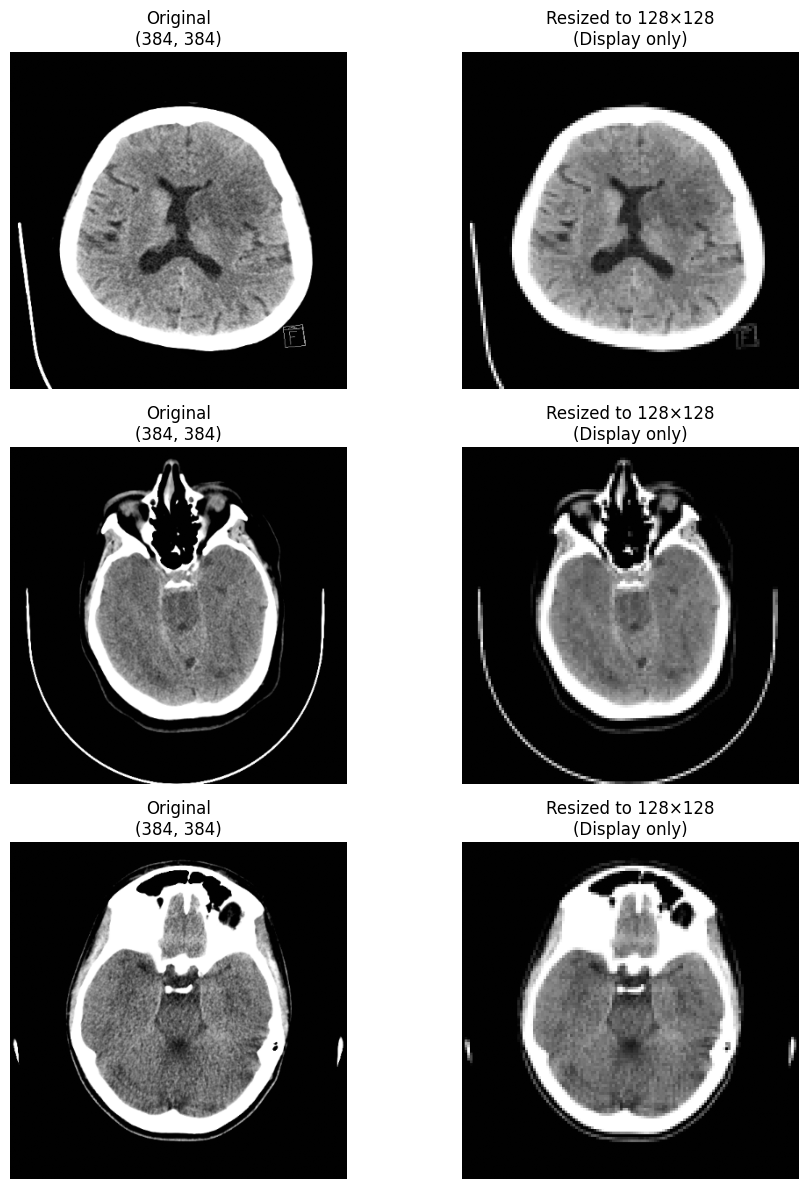

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Images to compare
selected_paths = [
    image_paths_test[510],
    image_paths[2390],
    image_paths[0]
]

plt.figure(figsize=(10, 12))

for i, path in enumerate(selected_paths):

    # Read original image
    original = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Resize to 128x128
    resized = cv2.resize(original, (128, 128), interpolation=cv2.INTER_AREA)

    # Enlarge resized image back to original size for visualization only
    resized_display = cv2.resize(
        resized,
        (384, 384),
        interpolation=cv2.INTER_NEAREST
    )

    # Original image
    plt.subplot(len(selected_paths), 2, 2*i + 1)
    plt.imshow(original, cmap='gray')
    plt.title(f"Original\n{original.shape}")
    plt.axis('off')

    # Resized image
    plt.subplot(len(selected_paths), 2, 2*i + 2)
    plt.imshow(resized_display, cmap='gray')
    plt.title(f"Resized to 128×128\n(Display only)")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
## since the difference in above is acceptable and classes still reecognizable so we resized image size to 128*128 to make their reading faster and reduce feature numbers in future models
import cv2
import numpy as np

IMG_SIZE = 128 # fast processing
batch_size = 500

train_batches = []
train_label_batches = []

for start in range(0, len(image_paths), batch_size):
    end = min(start + batch_size, len(image_paths))

    batch_paths = image_paths[start:end]
    batch_labels = labels[start:end]

    batch_images = []

    for path in batch_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # shrink image
        batch_images.append(img)

    batch_images = np.array(batch_images)
    batch_labels = np.array(batch_labels)

    # Save this batch
    train_batches.append(batch_images)
    train_label_batches.append(batch_labels)

    print(batch_images.shape)

# Concatenate all training batches
X_train = np.concatenate(train_batches, axis=0)
y_train = np.concatenate(train_label_batches, axis=0)

print(X_train.shape)
print(y_train.shape)

(500, 128, 128)
(500, 128, 128)
(500, 128, 128)
(500, 128, 128)
(396, 128, 128)
(2396, 128, 128)
(2396,)


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 128
batch_size = 500

test_batches = []
test_label_batches = []

for start in range(0, len(image_paths_test), batch_size):
    end = min(start + batch_size, len(image_paths_test))

    batch_paths = image_paths_test[start:end]
    batch_labels = labels_test[start:end]

    batch_images = []

    for path in batch_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # shrink image
        batch_images.append(img)

    batch_images = np.array(batch_images)
    batch_labels = np.array(batch_labels)

    # Save this batch
    test_batches.append(batch_images)
    test_label_batches.append(batch_labels)

    print(batch_images.shape)

# Concatenate all training batches
X_test = np.concatenate(test_batches, axis=0)
y_test = np.concatenate(test_label_batches, axis=0)

print(X_test.shape)
print(y_test.shape) #labels

(500, 128, 128)
(14, 128, 128)
(514, 128, 128)
(514,)


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 128     # smaller size to be much faster to read and process
batch_size = 500

val_batches = []
val_label_batches = []

for start in range(0, len(image_paths_val), batch_size):
    end = min(start + batch_size, len(image_paths_val))

    batch_paths = image_paths_val[start:end]
    batch_labels = labels_val[start:end]

    batch_images = []

    for path in batch_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # shrink image
        batch_images.append(img)

    batch_images = np.array(batch_images)
    batch_labels = np.array(batch_labels)

    val_batches.append(batch_images)
    val_label_batches.append(batch_labels)

    print(batch_images.shape)

X_val = np.concatenate(val_batches, axis=0)
y_val = np.concatenate(val_label_batches, axis=0)

print(X_val.shape)
print(y_val.shape)

(500, 128, 128)
(13, 128, 128)
(513, 128, 128)
(513,)


In [ ]:
## normalize

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0

In [ ]:
## Model 1 (Random Forest)  -> Machine Learning

## first flatten
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(X_train_flat.shape)
print(X_test_flat.shape)



(2396, 16384)
(514, 16384)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True],
    'max_samples': [0.6, 0.8, 1.0]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Searching for best Random Forest parameters...")
random_search.fit(X_train_flat, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

Searching for best Random Forest parameters...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 1.0, 'max_depth': 20, 'bootstrap': True}


Final Accuracy of the Best Model: 76.46%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.71      0.73       180
    Ischemia       0.75      0.81      0.78       170
    Bleeding       0.79      0.77      0.78       164

    accuracy                           0.76       514
   macro avg       0.77      0.77      0.76       514
weighted avg       0.76      0.76      0.76       514



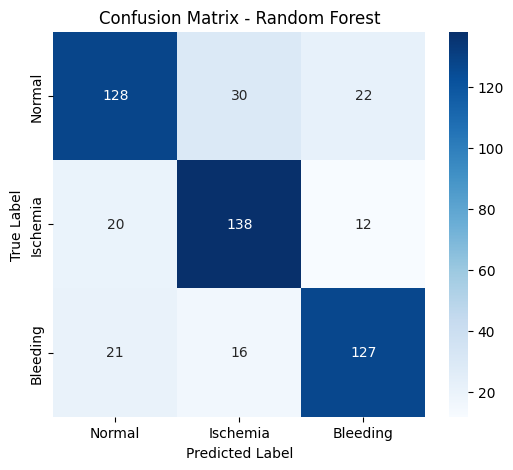

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sb

# Predict on the test set
y_pred = best_model.predict(X_test_flat)

# Accuracy
acc = accuracy_score(y_test, y_pred) * 100
print(f"Final Accuracy of the Best Model: {acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Ischemia", "Bleeding"]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Ischemia", "Bleeding"],
    yticklabels=["Normal", "Ischemia", "Bleeding"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
## Another Version with PCA to compare results
from sklearn.decomposition import PCA

# Keep 95% of the information
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("Original shape:", X_train_flat.shape)
print("After PCA:", X_train_pca.shape)
print("Number of principal components:", pca.n_components_)


Original shape: (2396, 16384)
After PCA: (2396, 685)
Number of principal components: 685


In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True],
    'max_samples': [0.6, 0.8, 1.0]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Searching for best Random Forest parameters...")
random_search.fit(X_train_pca, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

Searching for best Random Forest parameters...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_depth': 30, 'bootstrap': True}


Final Accuracy of the Best Model: 73.35%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.69      0.69      0.69       180
    Ischemia       0.67      0.87      0.76       170
    Bleeding       0.93      0.63      0.75       164

    accuracy                           0.73       514
   macro avg       0.76      0.73      0.73       514
weighted avg       0.76      0.73      0.73       514



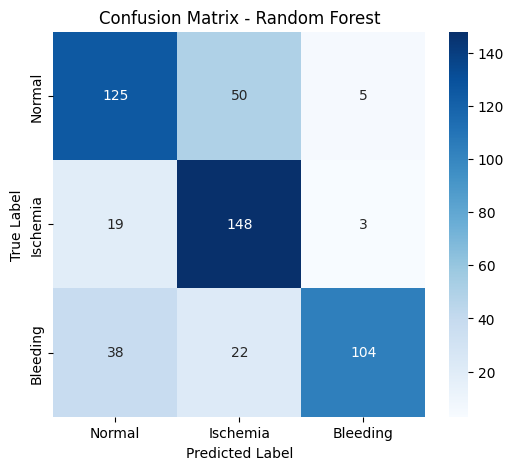

In [ ]:
# Predict on the test set
y_pred = best_model.predict(X_test_pca)

# Accuracy
acc = accuracy_score(y_test, y_pred) * 100
print(f"Final Accuracy of the Best Model: {acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Ischemia", "Bleeding"]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Ischemia", "Bleeding"],
    yticklabels=["Normal", "Ischemia", "Bleeding"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
## SVM Model

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# Parameter search space
param_dist = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

svm = SVC(random_state=42)

random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Searching for best SVM parameters...")

random_search.fit(X_train_pca, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

Searching for best SVM parameters...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

Best Parameters:
{'kernel': 'rbf', 'gamma': 'scale', 'C': 10}


Accuracy: 85.80%
              precision    recall  f1-score   support

      Normal       0.86      0.79      0.82       180
    Ischemia       0.84      0.94      0.89       170
    Bleeding       0.89      0.85      0.87       164

    accuracy                           0.86       514
   macro avg       0.86      0.86      0.86       514
weighted avg       0.86      0.86      0.86       514



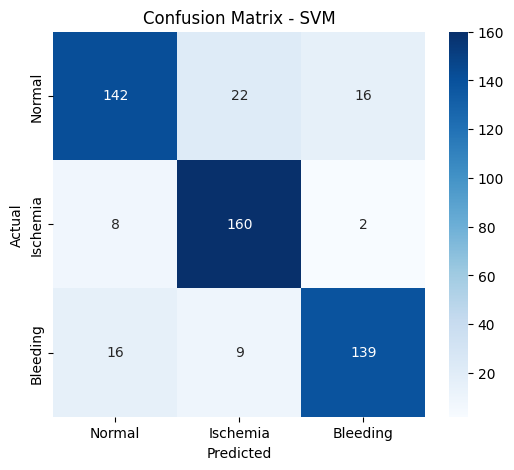

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sb

y_pred = best_model.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Ischemia", "Bleeding"]
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Ischemia", "Bleeding"],
    yticklabels=["Normal", "Ischemia", "Bleeding"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

In [ ]:
## to see effect of PCA on SVM, let's do a model without PCA
## SVM Model (Without PCA)

# Parameter search space
param_dist = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

# Initialize SVM
svm = SVC(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Searching for best SVM parameters...")

# Use flattened images
random_search.fit(X_train_flat, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

# Best model
best_model = random_search.best_estimator_

Searching for best SVM parameters...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

Best Parameters:
{'kernel': 'rbf', 'gamma': 'scale', 'C': 10}


Accuracy: 85.99%
              precision    recall  f1-score   support

      Normal       0.86      0.81      0.83       180
    Ischemia       0.83      0.94      0.88       170
    Bleeding       0.90      0.84      0.87       164

    accuracy                           0.86       514
   macro avg       0.86      0.86      0.86       514
weighted avg       0.86      0.86      0.86       514



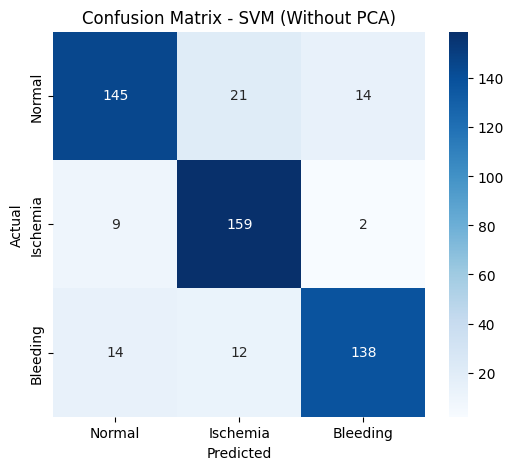

In [ ]:
# Predict on test set
y_pred = best_model.predict(X_test_flat)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

# Classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Ischemia", "Bleeding"]
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Ischemia", "Bleeding"],
    yticklabels=["Normal", "Ischemia", "Bleeding"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM (Without PCA)")
plt.show()

In [ ]:
#### Deep Learning Models
import numpy as np

# Convert grayscale to 3-channel for EfficientNetB0
X_train_rgb = np.repeat(X_train[..., np.newaxis], 3, axis=-1)  # (N,128,128,3)
X_val_rgb   = np.repeat(X_val[..., np.newaxis], 3, axis=-1)
X_test_rgb  = np.repeat(X_test[..., np.newaxis], 3, axis=-1)

print(X_train_rgb.shape, X_val_rgb.shape, X_test_rgb.shape)

(2396, 128, 128, 3) (513, 128, 128, 3) (514, 128, 128, 3)


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input


X_train_eff = preprocess_input(X_train_rgb * 255.0)
X_val_eff   = preprocess_input(X_val_rgb * 255.0)
X_test_eff  = preprocess_input(X_test_rgb * 255.0)

In [ ]:
## Model 3 (EfficientNetB0)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

#building model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # freeze for stage 1

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes: Normal, Ischemic, Hemorrhagic
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# train stage 1 with early stopping using the val set
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# save the best stage-1 model to disk, so fine-tuning can never lose it
checkpoint_stage1 = ModelCheckpoint(
    'best_stage1_model.keras',
    monitor='val_loss',
    save_best_only=True
)
history = model.fit(
    X_train_eff, y_train,
    validation_data=(X_val_eff, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop, checkpoint_stage1]
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 90s 474ms/step - accuracy: 0.5881 - loss: 0.8879 - val_accuracy: 0.6647 - val_loss: 0.7616
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 63s 419ms/step - accuracy: 0.6770 - loss: 0.7367 - val_accuracy: 0.6901 - val_loss: 0.7054
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 91s 482ms/step - accuracy: 0.7287 - loss: 0.6545 - val_accuracy: 0.6647 - val_loss: 0.6997
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 477ms/step - accuracy: 0.7462 - loss: 0.6082 - val_accuracy: 0.7271 - val_loss: 0.6875
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 435ms/step - accuracy: 0.7567 - loss: 0.5798 - val_accuracy: 0.7193 - val_loss: 0.6286
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 483ms/step - accuracy: 0.7896 - loss: 0.5246 - val_accuracy: 0.7310 - val_loss: 0.6109
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 66s 441ms/step - accuracy: 0.7922 - loss: 0.4975 - val_accuracy: 0.7563 - val_loss: 0.6070
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 430ms/step - accuracy: 0.8051 - loss: 0

In [ ]:
import tensorflow as tf

# stage 2 (unfreaze top layers and then doing fine-tune)
base_model.trainable = True

# freeze all but the last approx 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# BatchNorm layers store stable average values learned from millions of ImageNet images.
# If left trainable, they will recalculate those averages using only our small CT scan batches,
# which can corrupt good pretrained values instead of improving them.
# So even within the last 30 unfrozen layers, force any BatchNorm layer to stay frozen.

for layer in base_model.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

checkpoint_stage2 = ModelCheckpoint(
    'best_stage2_model.keras',
    monitor='val_loss',
    save_best_only=True
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X_train_eff, y_train,
    validation_data=(X_val_eff, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop, checkpoint_stage2]
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 101s 542ms/step - accuracy: 0.9403 - loss: 0.1747 - val_accuracy: 0.8168 - val_loss: 0.5074
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 82s 543ms/step - accuracy: 0.9403 - loss: 0.1705 - val_accuracy: 0.8109 - val_loss: 0.5087
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 87s 579ms/step - accuracy: 0.9445 - loss: 0.1713 - val_accuracy: 0.8090 - val_loss: 0.5072
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 145s 597ms/step - accuracy: 0.9491 - loss: 0.1568 - val_accuracy: 0.8031 - val_loss: 0.5042
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 82s 545ms/step - accuracy: 0.9424 - loss: 0.1611 - val_accuracy: 0.8051 - val_loss: 0.5228


In [ ]:
# pick whichever stage actually performed better on val_loss
best_stage1_val_loss = min(history.history['val_loss'])
best_stage2_val_loss = min(history_fine.history['val_loss'])

print("Best stage 1 val_loss:", best_stage1_val_loss)
print("Best stage 2 val_loss:", best_stage2_val_loss)

if best_stage2_val_loss < best_stage1_val_loss:
    print("Using fine-tuned model (stage 2)")
    final_model = tf.keras.models.load_model('best_stage2_model.keras')
else:
    print("Using frozen-backbone model (stage 1) — fine-tuning did not improve results")
    final_model = tf.keras.models.load_model('best_stage1_model.keras')

Best stage 1 val_loss: 0.5393842458724976
Best stage 2 val_loss: 0.5042340755462646
Using fine-tuned model (stage 2)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import numpy as np

# model predictions on the test set
y_pred_probs = final_model.predict(X_test_eff)
y_pred = np.argmax(y_pred_probs, axis=1) # convert probabilities to class labels

# overall accuracy
test_loss, test_acc = final_model.evaluate(X_test_eff, y_test)
print("Test accuracy:", test_acc)

# F1 score
f1_macro = f1_score(y_test, y_pred, average='macro')
print("F1 score:", f1_macro)

# precision, recall, F1 per class
# support is for the number of the actual samples
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ischemic', 'Hemorrhagic']))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 744ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 620ms/step - accuracy: 0.8463 - loss: 0.4111
Test accuracy: 0.8463035225868225
F1 score: 0.8461206868307126
              precision    recall  f1-score   support

      Normal       0.86      0.83      0.85       180
    Ischemic       0.85      0.81      0.83       170
 Hemorrhagic       0.83      0.90      0.87       164

    accuracy                           0.85       514
   macro avg       0.85      0.85      0.85       514
weighted avg       0.85      0.85      0.85       514

Confusion matrix:
[[150  17  13]
 [ 16 137  17]
 [  9   7 148]]


In [ ]:
## Model: ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# preprocess (reuse the *_rgb arrays already built for EfficientNet)
X_train_res = resnet_preprocess(X_train_rgb * 255.0)
X_val_res   = resnet_preprocess(X_val_rgb * 255.0)
X_test_res  = resnet_preprocess(X_test_rgb * 255.0)

# build model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # stage 1: frozen backbone

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Stage 1 training
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint_stage1 = ModelCheckpoint('best_resnet_stage1.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train_res, y_train,
    validation_data=(X_val_res, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop, checkpoint_stage1]
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.5747 - loss: 1.0045 - val_accuracy: 0.6706 - val_loss: 0.7586
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6778 - loss: 0.7234 - val_accuracy: 0.6998 - val_loss: 0.6975
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.7170 - loss: 0.6391 - val_accuracy: 0.6823 - val_loss: 0.7027
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.7454 - loss: 0.6083 - val_accuracy: 0.7212 - val_loss: 0.6505
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 149s 994ms/step - accuracy: 0.7654 - loss: 0.5462 - val_accuracy: 0.7407 - val_loss: 0.6367
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 148s 986ms/step - accuracy: 0.7876 - loss: 0.5163 - val_accuracy: 0.7193 - val_loss: 0.6429
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.8013 - loss: 0.4775 - val_accuracy: 0.7505 - val_loss: 0.6069
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8126 - loss: 0.4668 - va

In [ ]:
# Stage 2: unfreeze top layers, fine-tune
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

checkpoint_stage2 = ModelCheckpoint('best_resnet_stage2.keras', monitor='val_loss', save_best_only=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X_train_res, y_train,
    validation_data=(X_val_res, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop, checkpoint_stage2]
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.8397 - loss: 0.3888 - val_accuracy: 0.7758 - val_loss: 0.5401
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.9065 - loss: 0.2555 - val_accuracy: 0.8090 - val_loss: 0.5152
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9407 - loss: 0.1826 - val_accuracy: 0.8226 - val_loss: 0.4902
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.9599 - loss: 0.1172 - val_accuracy: 0.8343 - val_loss: 0.4870
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.9720 - loss: 0.0867 - val_accuracy: 0.8168 - val_loss: 0.5549
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.9829 - loss: 0.0545 - val_accuracy: 0.8070 - val_loss: 0.6709
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.9896 - loss: 0.0406 - val_accuracy: 0.8382 - val_loss: 0.6114
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9887 - loss: 0.0400 - val_accu

In [ ]:
# pick best stage
best_stage1_val_loss = min(history.history['val_loss'])
best_stage2_val_loss = min(history_fine.history['val_loss'])

if best_stage2_val_loss < best_stage1_val_loss:
    print("Using fine-tuned model (stage 2)")
    final_model = tf.keras.models.load_model('best_resnet_stage2.keras')
else:
    print("Using frozen-backbone model (stage 1)")
    final_model = tf.keras.models.load_model('best_resnet_stage1.keras')

Using fine-tuned model (stage 2)


In [ ]:
# evaluation
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

y_pred_probs = final_model.predict(X_test_res)
y_pred = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc = final_model.evaluate(X_test_res, y_test)
print("Test accuracy:", test_acc)

f1_macro = f1_score(y_test, y_pred, average='macro')
print("F1 score:", f1_macro)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Ischemic', 'Hemorrhagic']))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8521 - loss: 0.5344
Test accuracy: 0.8521400690078735
F1 score: 0.8520322645326109
              precision    recall  f1-score   support

      Normal       0.83      0.88      0.85       180
    Ischemic       0.88      0.84      0.86       170
 Hemorrhagic       0.85      0.84      0.84       164

    accuracy                           0.85       514
   macro avg       0.85      0.85      0.85       514
weighted avg       0.85      0.85      0.85       514

Confusion matrix:
[[158   9  13]
 [ 16 142  12]
 [ 16  10 138]]
